BRAIN TUMOR DETECTION


.....................................

In [ ]:
# Block 1
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D,Flatten, Dense
import cv2

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
train_path = path + "/Training"
test_path = path + "/Testing"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
# Block 5
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# Block 6
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),   # 🔥 Better than Flatten

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Block 7
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Block 9
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 215ms/step - accuracy: 0.4761 - loss: 1.1039 - val_accuracy: 0.5825 - val_loss: 1.2308
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.6307 - loss: 0.8820 - val_accuracy: 0.6469 - val_loss: 1.0390
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.7050 - loss: 0.7406 - val_accuracy: 0.6094 - val_loss: 1.1146
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.7275 - loss: 0.6757 - val_accuracy: 0.6619 - val_loss: 0.9341
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.7614 - loss: 0.6222 - val_accuracy: 0.6388 - val_loss: 1.0504
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.7725 - loss: 0.5824 - val_accuracy: 0.6894 - val_loss: 0.8973
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.7882 - loss: 0.5543 - val_accuracy: 0.6881 - val_loss: 0.9519
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.7970 - loss: 0.5314

In [ ]:
# Block 10
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7069 - loss: 0.8773
Test Accuracy: 0.7068750262260437


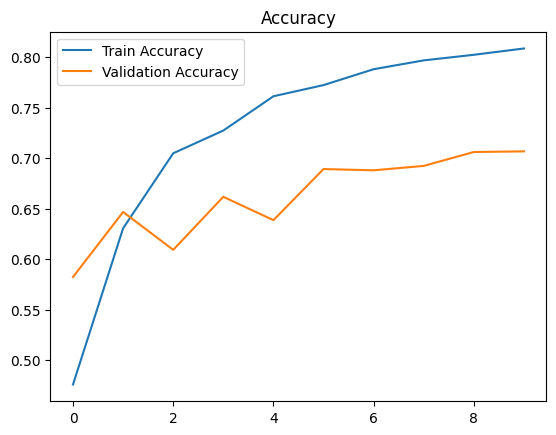

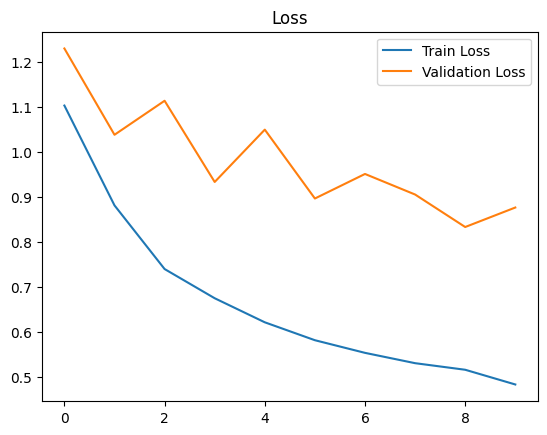

In [ ]:
# Block 11
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
# Block 12
def get_gradcam(img_array, model, last_conv_layer_name):

    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_max(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
import random
import os

folder = test_path + "/glioma"

img_name = random.choice(os.listdir(folder))

img_path = folder + "/" + img_name

print("Selected image:", img_path)

Selected image: /kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_118.jpg


In [ ]:
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
last_conv_layer = None

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name

print("Last Conv Layer:", last_conv_layer)

Last Conv Layer: conv2d_9
